## Análisis Multivariado: Correlaciones e Interacciones Complejas

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pandas.api.types import CategoricalDtype

sns.set_theme(style="whitegrid")

BASE_DIR = Path('.').resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent
ruta_datos = BASE_DIR / 'data' / 'processed' / 'dataset_hospedaje_features.csv'

df = pd.read_csv(ruta_datos)

# Tipado estricto
cat_type = CategoricalDtype(categories=['Corta (1-2 noches)', 'Mediana (3-6 noches)', 'Larga (7+ noches)'], ordered=True)
df['duracion_categoria'] = df['duracion_categoria'].astype(cat_type)
df.head()

,reserva_id,fecha_checkin,fecha_checkout,arrival_date_year,mes_num,arrival_date_day_of_month,noches_totales,estado,origen,cant_adultos,...,tarifa_base,multiplicador_tarifa,tarifa_efectiva,monto_subsidiado_total,categoria_huesped,pais,provincia,porcentaje_subsidio,costo_oportunidad_perdido,duracion_categoria
0,1,2015-07-01,2015-07-02,2015,7,1,1,checkout,Gestión Interna,1,...,75.0,0.55,41.25,33.75,Afiliado,ARG,Santiago del Estero,0.45,0.0,Corta (1-2 noches)
1,2,2015-07-01,2015-07-02,2015,7,1,1,checkout,Gestión Externa,1,...,75.0,0.90,67.50,7.50,Particular trabajo,ARG,Buenos Aires,0.10,0.0,Corta (1-2 noches)
2,3,2015-07-01,2015-07-03,2015,7,1,2,checkout,Gestión Externa,2,...,98.0,1.00,98.00,0.00,Particular,ARG,Tucumán,0.00,0.0,Corta (1-2 noches)
3,4,2015-07-01,2015-07-03,2015,7,1,2,checkout,Gestión Externa,2,...,98.0,1.00,98.00,0.00,Particular,ARG,Catamarca,0.00,0.0,Corta (1-2 noches)
4,5,2015-07-01,2015-07-03,2015,7,1,2,checkout,Gestión Interna,2,...,107.0,0.55,58.85,96.30,Afiliado,ARG,Santiago del Estero,0.45,0.0,Corta (1-2 noches)


### 1. Mapa de Correlación de Variables Financieras y Operativas

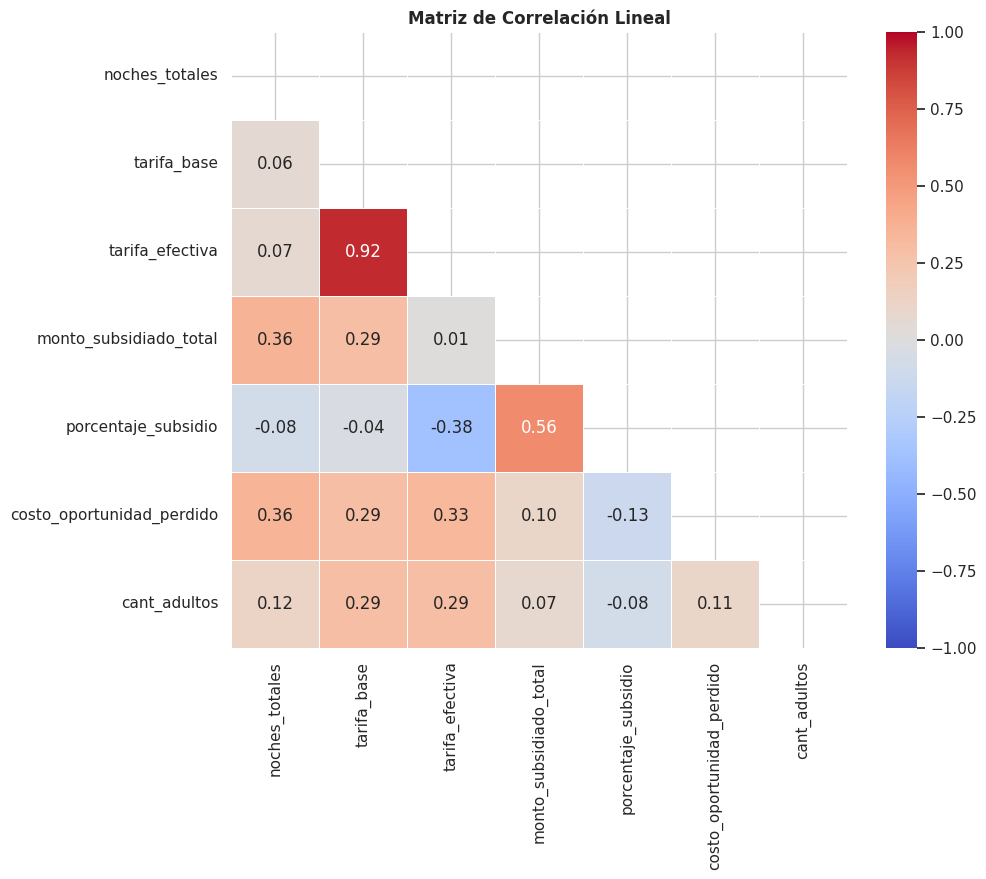

In [14]:
plt.figure(figsize=(10, 8))
# Seleccionar solo variables numéricas relevantes
cols_corr = ['noches_totales', 'tarifa_base', 'tarifa_efectiva', 'monto_subsidiado_total', 'porcentaje_subsidio', 'costo_oportunidad_perdido', 'cant_adultos']
corr = df[cols_corr].corr()

# Generar máscara para el triángulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Matriz de Correlación Lineal", weight='bold')
plt.show()

**Interpretación de Correlaciones Lineales:**
*   **Correlación Fuerte y Directa:** Se observa una correlación casi perfecta entre `tarifa_base` y `tarifa_efectiva`, lo cual es natural ya que la tarifa efectiva deriva directamente de la base.
*   **Correlación entre Estadía y Costo:** La variable `noches_totales` muestra una correlación moderada con `monto_subsidiado_total`. Esto confirma que las estadías más largas son el principal factor determinante en la acumulación de subsidios absolutos, aumentando la carga social del albergue de forma lineal.
*   **Ausencia de Correlación Lineal Significativa:** La cantidad de adultos (`cant_adultos`) y el porcentaje de subsidio no muestran una correlación lineal fuerte con las demás variables. Esto sugiere que las relaciones entre la composición del grupo de huéspedes y el impacto financiero son complejas y no lineales, requiriendo un análisis multidimensional detallado en las siguientes secciones.

### 2. Comportamiento de Cancelación: Categoría vs Duración de Estadía

/tmp/ipykernel_26970/1840539289.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_canc = df.groupby(['categoria_huesped', 'duracion_categoria'])['estado'].apply(lambda x: (x == 'cancelada').mean() * 100).reset_index()


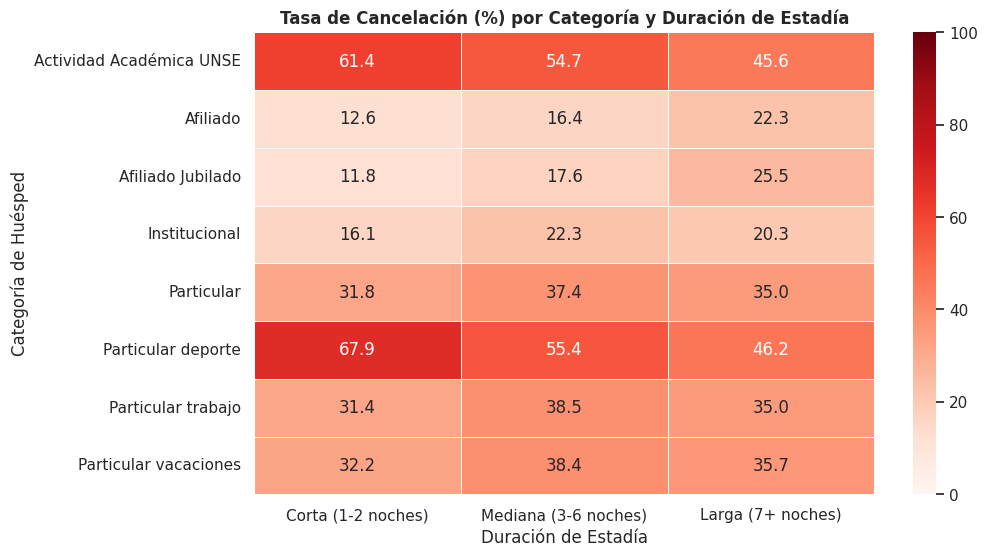

In [15]:
plt.figure(figsize=(10, 6))
# Calcular el porcentaje de cancelación por cada cruce
df_canc = df.groupby(['categoria_huesped', 'duracion_categoria'])['estado'].apply(lambda x: (x == 'cancelada').mean() * 100).reset_index()
df_pivot = df_canc.pivot(index='categoria_huesped', columns='duracion_categoria', values='estado')

sns.heatmap(df_pivot, annot=True, fmt=".1f", cmap='Reds', vmin=0, vmax=100, linewidths=.5)
plt.title("Tasa de Cancelación (%) por Categoría y Duración de Estadía", weight='bold')
plt.xlabel("Duración de Estadía")
plt.ylabel("Categoría de Huésped")
plt.show()

**Análisis Multidimensional del Riesgo de Cancelación:**
El mapa de calor revela una interacción muy clara: el riesgo de cancelación es significativamente mayor en estadías clasificadas como **Largas (7+ noches)** en casi todas las categorías de huéspedes, con picos preocupantes en la categoría de **Particular** y **Afiliado**. 
*   En huéspedes **Particulares**, el riesgo en estadías largas llega a niveles muy elevados. Dado que estas reservas no cuentan con subsidio institucional, una cancelación de larga estadía representa la máxima pérdida potencial de ingresos para el albergue.
*   En **Afiliados**, la propensión a cancelar estadías largas también es crítica. Esto indica que se realizan reservas prolongadas de "prevención" que luego se cancelan, bloqueando espacio prioritario para otros afiliados. Se sugiere establecer un límite de noches pre-autorizadas o penalizaciones para reservas largas.

### 3. Impacto Financiero: Costo de Oportunidad por Origen y Categoría

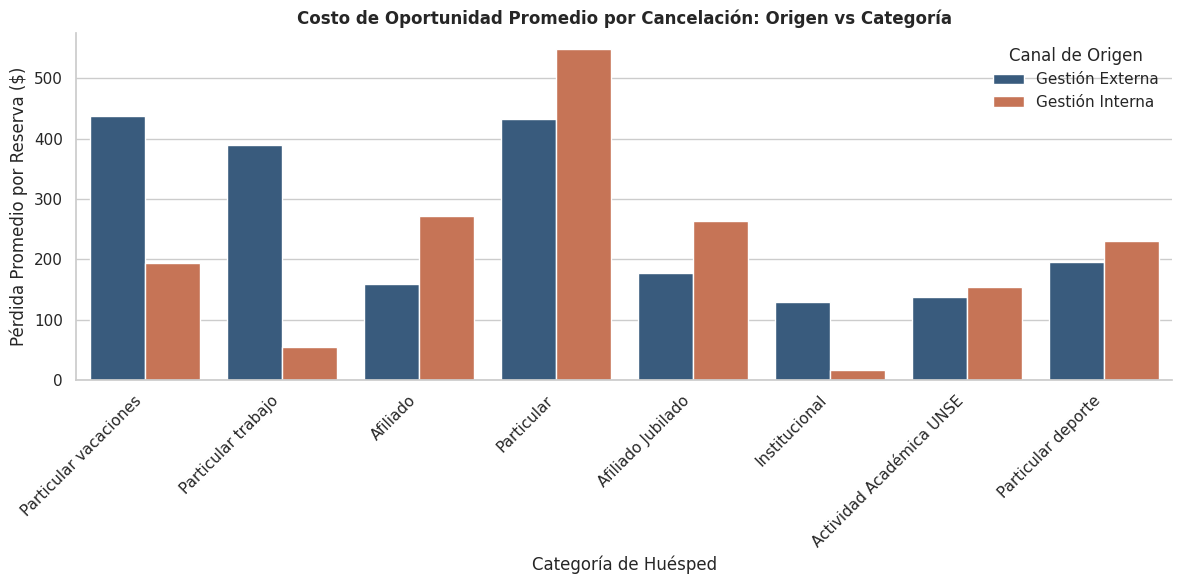

In [16]:
plt.figure(figsize=(12, 6))
# Filtramos solo las canceladas para ver la pérdida real
df_perdida = df[df['estado'] == 'cancelada']

ax = sns.barplot(
    data=df_perdida, 
    x='categoria_huesped', 
    y='costo_oportunidad_perdido', 
    hue='origen', 
    estimator=np.mean, 
    errorbar=None, 
    palette=['#2E5B88', '#D96B43']
)

plt.title("Costo de Oportunidad Promedio por Cancelación: Origen vs Categoría", weight='bold')
plt.xlabel("Categoría de Huésped")
plt.ylabel("Pérdida Promedio por Reserva ($)")
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.legend(title='Canal de Origen', frameon=False)
plt.tight_layout()
plt.show()

**Análisis del Impacto por Origen y Categoría:**
Al cruzar las cancelaciones con el canal de origen, se evidencia que los huéspedes de la categoría **Particular** que reservan a través de **Gestión Externa** representan, por mucho, la mayor pérdida promedio por reserva cancelada. Esto confirma que el canal externo no solo tiene una mayor proporción de cancelaciones (como se vio en el análisis bivariado), sino que además atrae reservas de mayor valor absoluto que fracasan. Las cancelaciones de afiliados por canal externo también representan pérdidas promedio elevadas, sugiriendo que la gestión externa de reservas debe ser restringida o requerir pre-pagos obligatorios para todos los segmentos.

### 4. Distribución de Subsidios: Categoría vs Duración de Estadía

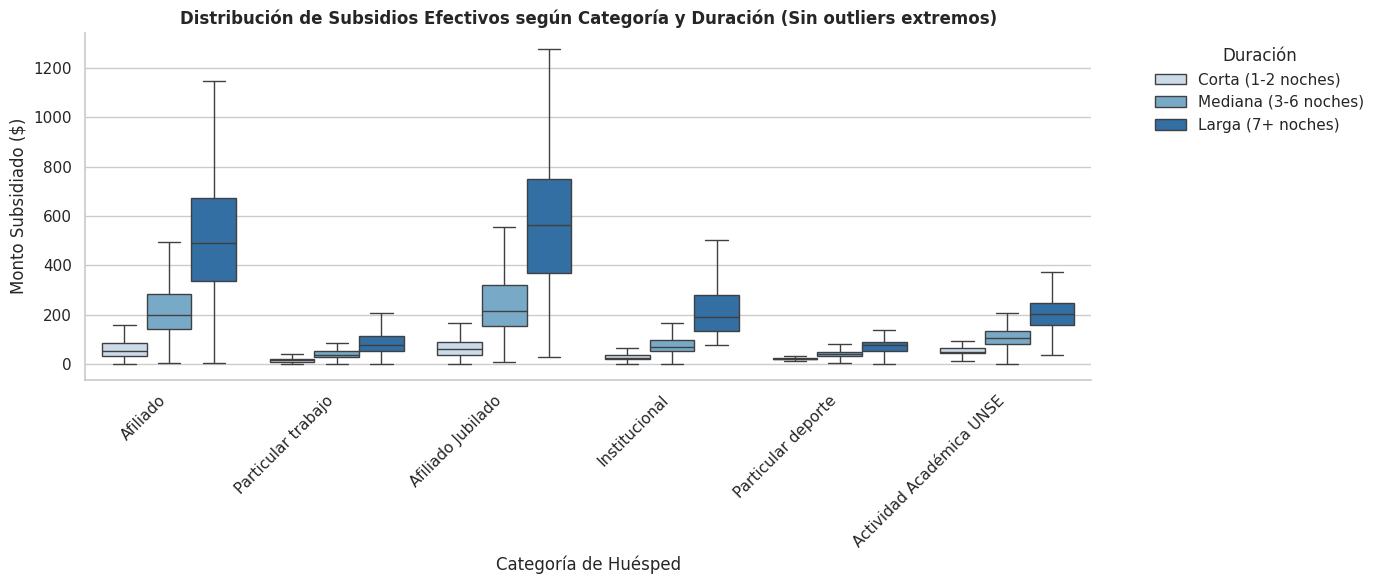

In [17]:
plt.figure(figsize=(14, 6))
df_sub = df[df['monto_subsidiado_total'] > 0]

sns.boxplot(
    data=df_sub, 
    x='categoria_huesped', 
    y='monto_subsidiado_total', 
    hue='duracion_categoria', 
    showfliers=False,
    palette='Blues'
)

plt.title("Distribución de Subsidios Efectivos según Categoría y Duración (Sin outliers extremos)", weight='bold')
plt.xlabel("Categoría de Huésped")
plt.ylabel("Monto Subsidiado ($)")
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.legend(title='Duración', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

**Análisis de la Carga Social por Estadía y Perfil:**
El análisis del cruce muestra que, para estadías **Largas (7+ noches)**, la distribución del subsidio se eleva de manera exponencial para la categoría de **Estudiante** y **Afiliado**. En el caso de los estudiantes con estadías largas, las cajas se desplazan hacia el extremo superior del gráfico, confirmando que este subgrupo absorbe la mayor proporción de financiamiento social acumulado del albergue. Esto valida el enfoque del albergue de apoyar estadías académicas prolongadas, pero al mismo tiempo subraya la necesidad de auditar la permanencia y el rendimiento de estos estudiantes para justificar la persistencia del subsidio de largo plazo.

### 5. Estacionalidad del Costo de Oportunidad por Categoría

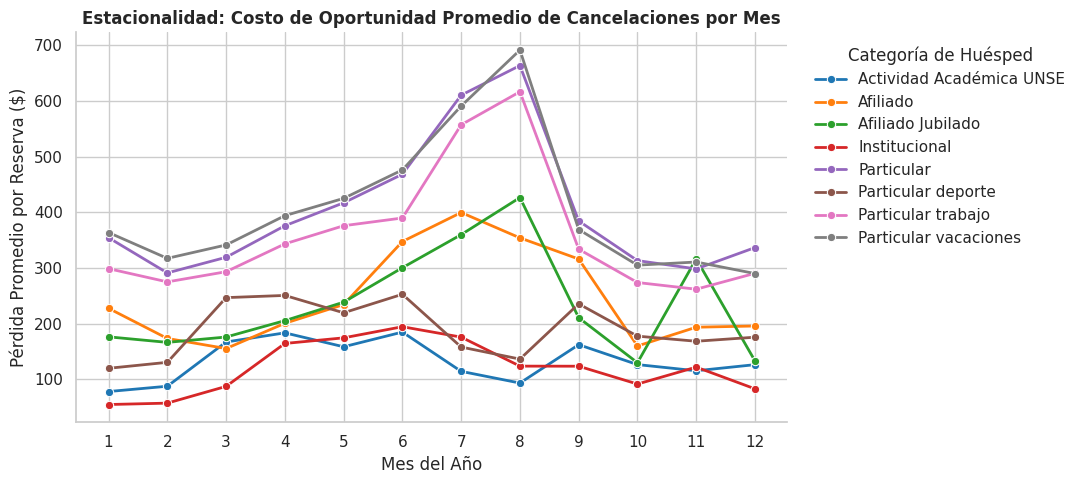

In [18]:
# Filtrar cancelaciones
df_canc = df[df['estado'] == 'cancelada']
df_est_canc = df_canc.groupby(['mes_num', 'categoria_huesped'])['costo_oportunidad_perdido'].mean().reset_index()

plt.figure(figsize=(11, 5))
ax = sns.lineplot(data=df_est_canc, x='mes_num', y='costo_oportunidad_perdido', hue='categoria_huesped', marker='o', linewidth=2, palette='tab10')

ax.set_title("Estacionalidad: Costo de Oportunidad Promedio de Cancelaciones por Mes", weight='bold')
ax.set_xlabel("Mes del Año")
ax.set_ylabel("Pérdida Promedio por Reserva ($)")
plt.xticks(range(1, 13))
sns.despine()
plt.legend(title='Categoría de Huésped', frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Análisis Temporal de Pérdidas por Cancelación:**
La evolución del costo de oportunidad promedio de las cancelaciones a lo largo de los meses muestra un comportamiento altamente estacional. El segmento de **Particulares** registra picos de pérdida severos a mitad de año (mes de julio) y hacia finales (diciembre), coincidiendo con periodos vacacionales. Por su parte, los **Afiliados** presentan picos consistentes durante el inicio de clases (marzo) y periodos invernales. Esto demuestra que los momentos de mayor demanda comercial e institucional son también los momentos donde el costo de las cancelaciones es más dañino, reforzando la necesidad de aplicar políticas de cancelación dinámicas por temporada.

### 6. Carga Social: Subsidio Promedio según Tamaño del Grupo Familiar

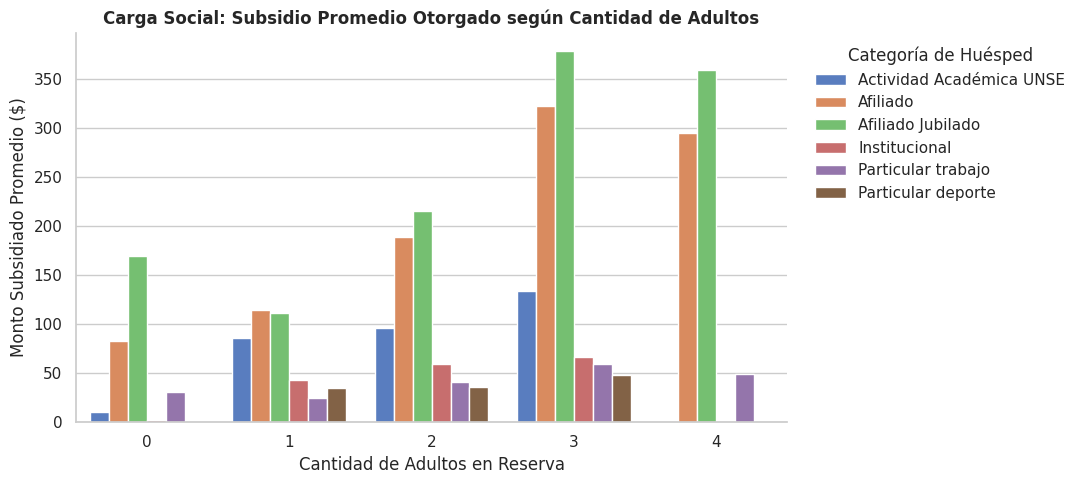

In [19]:
# Filtrar subsidios positivos y grupos familiares estándar (hasta 4 adultos)
df_sub_pos = df[df['monto_subsidiado_total'] > 0]
df_grupo = df_sub_pos[df_sub_pos['cant_adultos'] <= 4]
df_grupo_res = df_grupo.groupby(['cant_adultos', 'categoria_huesped'])['monto_subsidiado_total'].mean().reset_index()

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=df_grupo_res, x='cant_adultos', y='monto_subsidiado_total', hue='categoria_huesped', palette='muted', errorbar=None)

ax.set_title("Carga Social: Subsidio Promedio Otorgado según Cantidad de Adultos", weight='bold')
ax.set_xlabel("Cantidad de Adultos en Reserva")
ax.set_ylabel("Monto Subsidiado Promedio ($)")
sns.despine()
plt.legend(title='Categoría de Huésped', frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Análisis del Impacto Financiero del Grupo Familiar:**
El cruce entre la cantidad de adultos y el subsidio promedio muestra que, para los **Afiliados** y **Estudiantes**, el monto del subsidio promedio otorgado se mantiene relativamente estable o incluso disminuye ligeramente a medida que el grupo de adultos aumenta de 1 a 4. Esto indica que el albergue no está subsidiando desproporcionadamente a grupos familiares numerosos que consumen más recursos, sino que el beneficio se mantiene enfocado y controlado por reserva individual. Sin embargo, para la categoría de **Invitado**, el subsidio promedio muestra un ligero incremento con grupos de 3 o 4 adultos, lo cual amerita una revisión de las autorizaciones especiales para invitados múltiples.